Metin Sınıflandırma Akış Şeması:

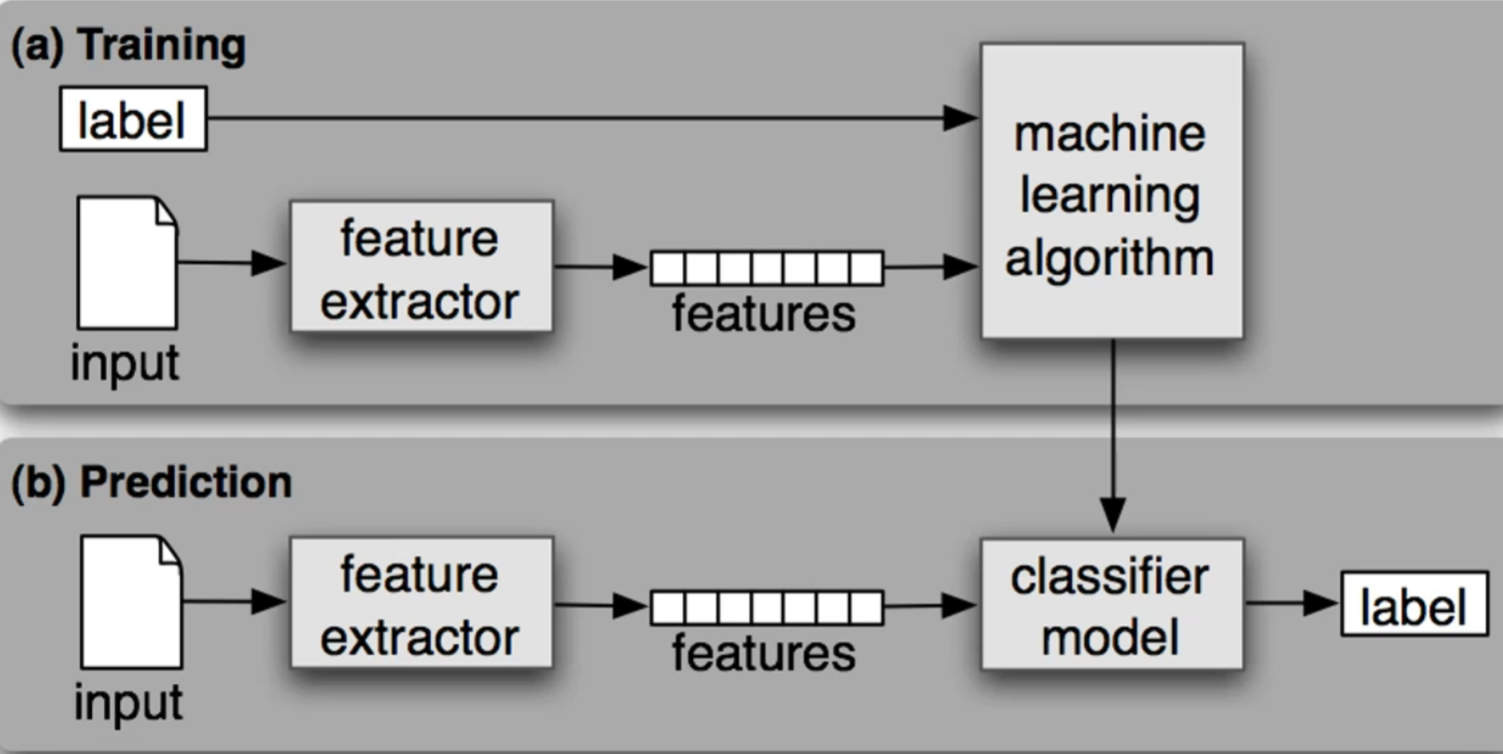

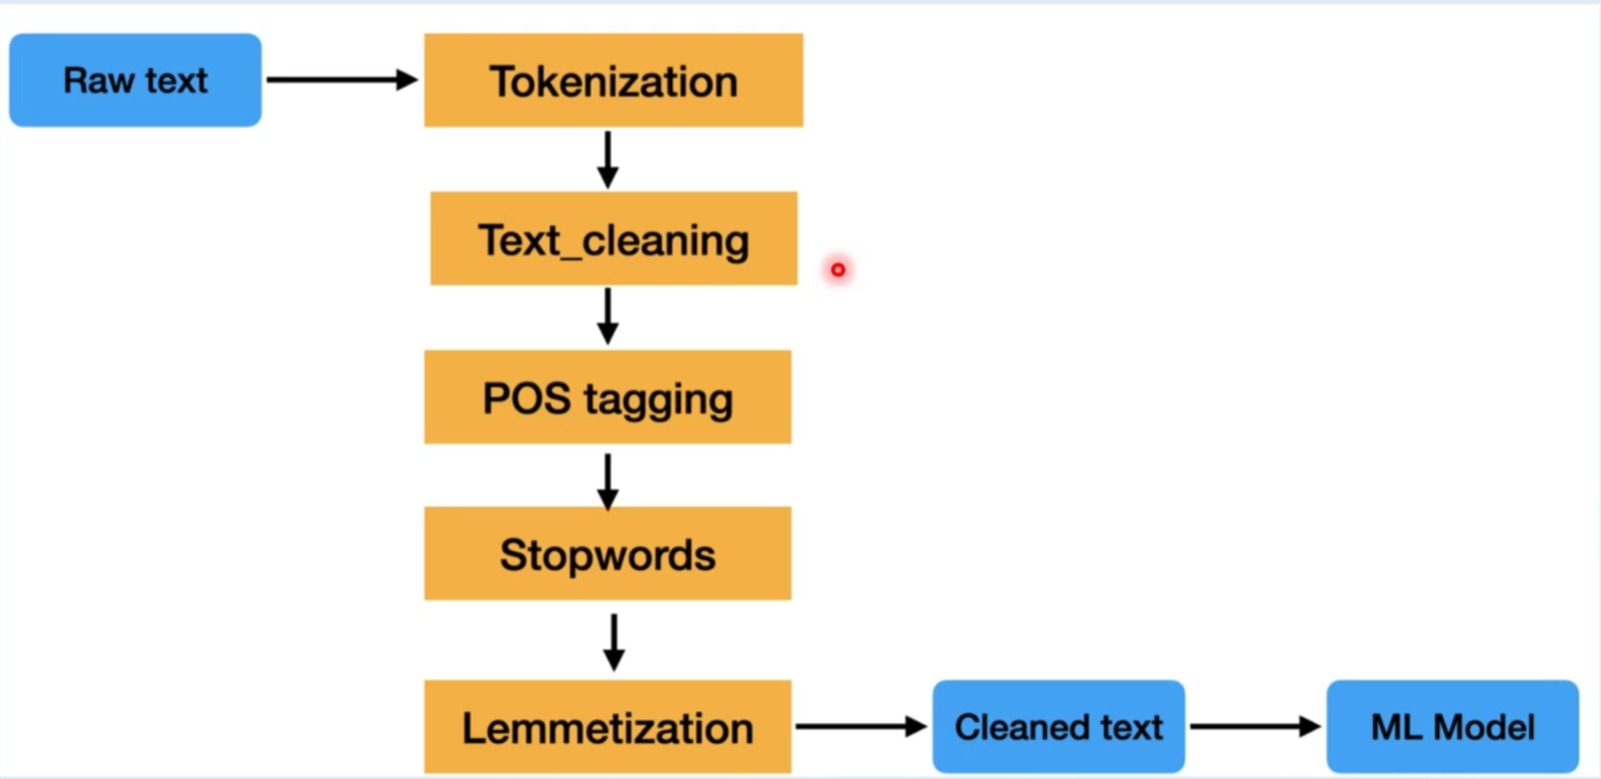

# 1- Kütüphaneler

In [1]:
import pandas as pd

# 2- Verinin Yüklenmesi

In [2]:
# Verimizi yükleyelim (Daha önce çalıştığımız spam veri setini kullanacağız)

data = pd.read_csv("spam.csv", encoding="latin-1")
data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1, inplace=True)
data.columns = ["label", "text"]
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# 3- EDA (Keşifsel Veri Analizi) Gerçekleştirilmesi

#### Missing Value (Kayıp Veri) İncelemesi

In [3]:
data.isna().sum()

# Kayıp verimiz yok

label    0
text     0
dtype: int64

# 4- Metin Ön İşleme (Text Preprocessing) Yapılması

#### Özel karakterlerin kaldırılması
#### Lowercase 
#### Tokenizasyon
#### Remove stopwords
#### lemmatize

In [4]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet") # WordNet, İngilizce kelimeler arasındaki ilişkileri içeren bir veritabanıdır. Kelime köklerini bulmak ve eşanlamlıları kullanmak için kullanılır.
nltk.download("omw-1.4") # farklı dillerdeki kelimeler için WordNet veritabanını genişletir.

[nltk_data] Downloading package stopwords to C:\Users\Bedirhan
[nltk_data]     Orseloglu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Bedirhan
[nltk_data]     Orseloglu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Bedirhan
[nltk_data]     Orseloglu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [10]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

text = list(data["text"])
lemmitizer = WordNetLemmatizer()
corpus = [] # en son temizlenmiş veriyi burada saklayacağız

# Metin temizleme işlemi yapalım
for i in range(len(text)):
    r = re.sub("[^a-zA-Z]", " ", text[i]) # sadece harfleri bırakır, diğer karakterleri boşluk yapar
    r = r.lower() # küçük harfe çevirir
    r = r.split() # kelimeleri ayırır
    r = [word for word in r if word not in stopwords.words("english")] # stopword'leri kaldırır 
    r = [lemmitizer.lemmatize(word) for word in r] # kelime köklerini bulur
    r = " ".join(r) # kelimeleri tekrar birleştirir
    corpus.append(r)

In [ ]:
# Temizlenmiş verilerden oluşan corpus listemizi veri setimize ekleyerek görelim

data["text2"] = corpus
data.head()

,label,text,text2
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


# 5- Train-Test Split Yapılması

In [16]:
x = data["text2"]
y = data["label"]

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

# 6- Öznitelik Çıkarımı (Feature Extraction)

#### Bag Of Words

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

x_train_cv = cv.fit_transform(x_train)
x_test_cv = cv.transform(x_test)

# 7- Modelin Oluşturulması ve Doğrulana

In [20]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

dtc.fit(x_train_cv, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [ ]:
y_pred = dtc.predict(x_test_cv)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# CM yorumu:
# [0,0] = 1573 -> gerçekte 0 biz de 0 tahmin ettik -> True Negative
# [0,1] = 14 -> gerçekte 0 biz de 1 tahmin ettik -> False Positive
# [1,0] = 34 -> gerçekte 1 biz de 0
# [1,1] = 219 -> gerçekte 1 biz de 1 tahmin ettik -> True Positive

# Yani toplamda 1573 + 219 = 1792 doğru tahmin yapmışız, 14 + 34 = 48 yanlış tahmin yapmışız. 

[[1573   14]
 [  34  218]]


In [ ]:
print("Accuracy: ", (1573 + 219) / (1573 + 14 + 34 + 219))

# Accuracy = (True Positive + True Negative) / (True Positive + True Negative + False Positive + False Negative)

Accuracy:  0.9739130434782609
